In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
import pandas as pd
df = pd.read_csv('/content/archive.zip')
print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 colu

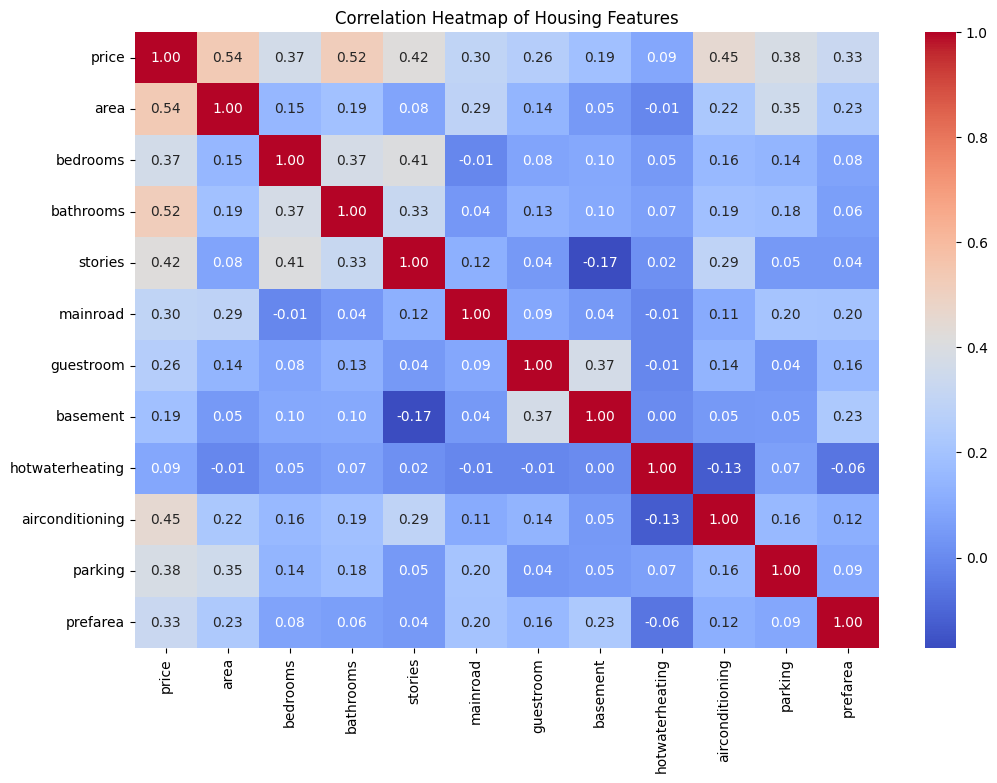

Model training complete


In [18]:
print(df.head())
print(df.info())
print(df.isnull().sum())


binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].apply(lambda x: 1 if x == 'yes' else 0)


df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)


numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Housing Features")
plt.show()

# Define features (x) and target (y) with 'price' as the target
x = df.drop('price', axis=1)
y = df['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train, y_train)
print("Model training complete")

🎯 FINAL MODEL EVALUATION
R-squared Score: 0.6529
Mean Squared Error: 1754318687330.66
Root Mean Squared Error: $1324506.96k


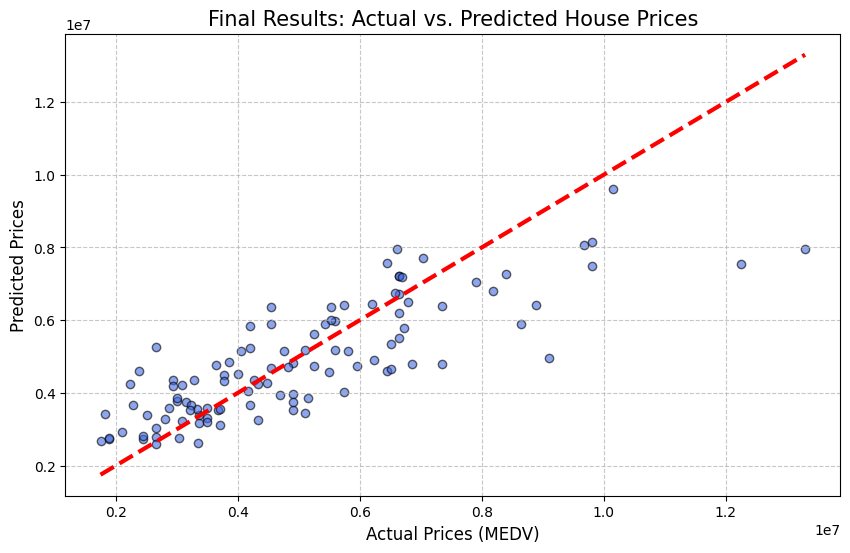

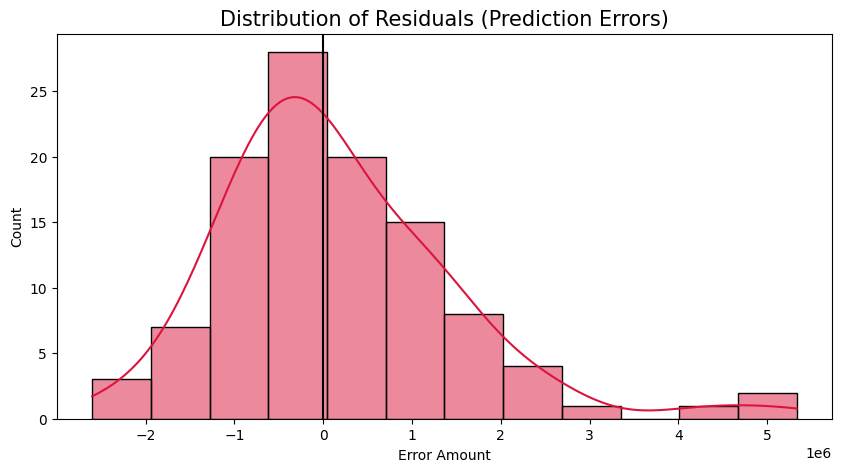

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

# 1. MAKE PREDICTIONS
y_pred = model.predict(x_test)

# 2. CALCULATE MATHEMATICAL METRICS
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("="*30)
print("🎯 FINAL MODEL EVALUATION")
print(f"R-squared Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: ${rmse:.2f}k")
print("="*30)

# 3. VISUALIZATION: ACTUAL VS. PREDICTED
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3)
plt.title('Final Results: Actual vs. Predicted House Prices', fontsize=15)
plt.xlabel('Actual Prices (MEDV)', fontsize=12)
plt.ylabel('Predicted Prices', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 4. ERROR DISTRIBUTION (Residual Analysis)
plt.figure(figsize=(10, 5))
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='crimson')
plt.axvline(x=0, color='black', linestyle='-')
plt.title('Distribution of Residuals (Prediction Errors)', fontsize=15)
plt.xlabel('Error Amount')
plt.show()